In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2
import os

In [2]:
os.listdir('dataset/')

['bird', 'drone']

In [8]:
len(os.listdir('dataset/bird/')) + len(os.listdir('dataset/drone/'))

4106

In [10]:
label = {
    'bird':0,
    'drone':1
}

In [12]:
X = []
y = []
for i in os.listdir('dataset/'):
    for j in os.listdir(f'dataset/{i}/'):
        image = mpimg.imread(f'dataset/{i}/{j}')
        image = cv2.resize(image, (224, 224))
        if len(image.shape) == 3:
            if image.shape[2] == 4 or image.shape[2] == 1:
                image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        else:
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = image / 255
        X.append(image)
        y.append(label[i])
X = np.array(X)
y = np.array(y)

In [28]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

y_train = to_categorical(y_train, 2)
y_test = to_categorical(y_test, 2)

In [29]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1
)

In [30]:
datagen.fit(X_train)

train_generator = datagen.flow(
    X_train,
    y_train,
    batch_size=32
)

In [31]:
X.shape

(4106, 224, 224, 3)

In [32]:
y.shape

(4106,)

In [33]:
X_train.shape

(3284, 224, 224, 3)

In [34]:
y_train.shape

(3284, 2)

In [36]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model

In [37]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

In [38]:
for layer in base_model.layers:
    layer.trainable = False

In [39]:
x = base_model.output
x = GlobalAveragePooling2D()(x)

x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)

output = Dense(2, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

In [40]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [41]:
history = model.fit(
    train_generator,
    validation_data=(X_test, y_test),
    epochs=5
)

Epoch 1/5
103/103 ━━━━━━━━━━━━━━━━━━━━ 57s 509ms/step - accuracy: 0.9525 - loss: 0.1264 - val_accuracy: 0.9866 - val_loss: 0.0641
Epoch 2/5
103/103 ━━━━━━━━━━━━━━━━━━━━ 54s 526ms/step - accuracy: 0.9762 - loss: 0.0653 - val_accuracy: 0.9866 - val_loss: 0.0579
Epoch 3/5
103/103 ━━━━━━━━━━━━━━━━━━━━ 78s 484ms/step - accuracy: 0.9836 - loss: 0.0509 - val_accuracy: 0.9903 - val_loss: 0.0408
Epoch 4/5
103/103 ━━━━━━━━━━━━━━━━━━━━ 55s 534ms/step - accuracy: 0.9893 - loss: 0.0322 - val_accuracy: 0.9757 - val_loss: 0.0861
Epoch 5/5
103/103 ━━━━━━━━━━━━━━━━━━━━ 78s 490ms/step - accuracy: 0.9869 - loss: 0.0366 - val_accuracy: 0.9732 - val_loss: 0.1087


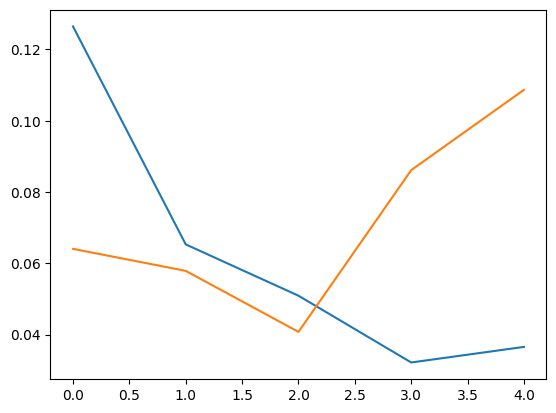

In [42]:
plt.plot(model.history.history['loss'])
plt.plot(model.history.history['val_loss'])

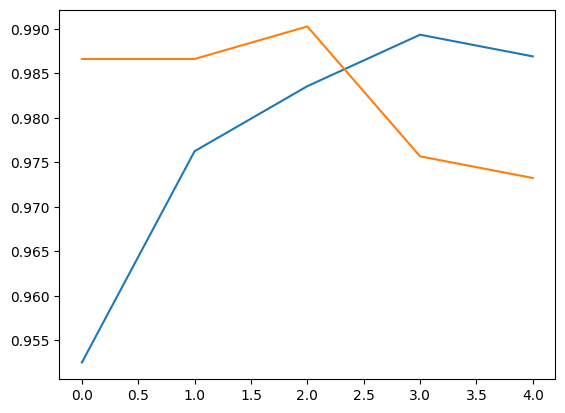

In [43]:
plt.plot(model.history.history['accuracy'])
plt.plot(model.history.history['val_accuracy'])

In [44]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)    │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1 (Conv2D)                │ (None, 112, 112, 32)      │             864 │ input_layer_1[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bn_Conv1 (BatchNormalization) │ (None, 112, 112, 32)      │             128 │ Conv1[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1_relu (ReLU)             │ (None, 112, 112, 32)      │               0 │ bn_Conv1[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise       │ (None, 112, 112, 32)      │             288 │ Conv1_relu[0][0]           │
│ (DepthwiseConv2D)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_BN    │ (None, 112, 112, 32)      │             128 │ expanded_conv_depthwise[0… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_relu  │ (None, 112, 112, 32)      │               0 │ expanded_conv_depthwise_B… │
│ (ReLU)                        │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project         │ (None, 112, 112, 16)      │             512 │ expanded_conv_depthwise_r… │
│ (Conv2D)                      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project_BN      │ (None, 112, 112, 16)      │              64 │ expanded_conv_project[0][… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand (Conv2D)       │ (None, 112, 112, 96)      │           1,536 │ expanded_conv_project_BN[… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_BN             │ (None, 112, 112, 96)      │             384 │ block_1_expand[0][0]       │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_relu (ReLU)    │ (None, 112, 112, 96)      │               0 │ block_1_expand_BN[0][0]    │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_pad (ZeroPadding2D)   │ (None, 113, 113, 96)      │               0 │ block_1_expand_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_depthwise             │ (None, 56, 56, 96)        │             864 │ block_1_pad[0][0]          │
│ (DepthwiseConv2D)             │                           │               

 Total params: 3,243,336 (12.37 MB)

 Trainable params: 328,450 (1.25 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 656,902 (2.51 MB)

In [45]:
for layer in base_model.layers[-30:]:
    layer.trainable = True

In [46]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [47]:
model.fit(
    train_generator,
    validation_data=(X_test, y_test),
    epochs=10
)

Epoch 1/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 72s 618ms/step - accuracy: 0.9501 - loss: 0.1439 - val_accuracy: 0.9611 - val_loss: 0.1839
Epoch 2/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 76s 556ms/step - accuracy: 0.9738 - loss: 0.0739 - val_accuracy: 0.9745 - val_loss: 0.1560
Epoch 3/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 86s 599ms/step - accuracy: 0.9762 - loss: 0.0613 - val_accuracy: 0.9708 - val_loss: 0.1616
Epoch 4/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 79s 566ms/step - accuracy: 0.9778 - loss: 0.0580 - val_accuracy: 0.9732 - val_loss: 0.1587
Epoch 5/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 61s 593ms/step - accuracy: 0.9893 - loss: 0.0357 - val_accuracy: 0.9769 - val_loss: 0.1309
Epoch 6/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 82s 598ms/step - accuracy: 0.9857 - loss: 0.0414 - val_accuracy: 0.9830 - val_loss: 0.1168
Epoch 7/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 82s 596ms/step - accuracy: 0.9887 - loss: 0.0316 - val_accuracy: 0.9866 - val_loss: 0.0946
Epoch 8/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 61s 596ms/step - accuracy: 0.9893 - loss: 0

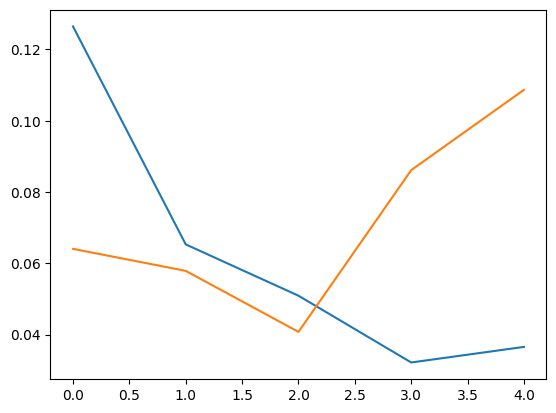

In [50]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

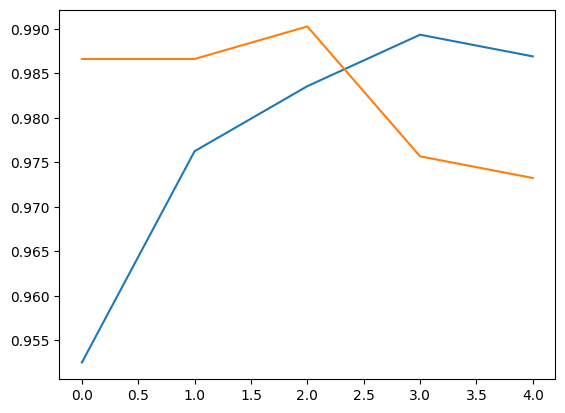

In [51]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

In [59]:
label = {
    0:'bird',
    1:'drone'
}

In [75]:
image = mpimg.imread('BionicBird-Deluxe-Biomimetic-Drone-04.jpg')

In [76]:
image = cv2.resize(image, (224, 224))
image = image.reshape(1, 224, 224, 3)
image = image / 255

In [77]:
label[np.argmax(model.predict(image))]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step


'bird'